In [2]:
import pandas as pd

df = pd.read_csv("accidents_weather_ca_merged.csv")

df["Severity_Binary"] = df["Severity"].apply(lambda x: 0 if x == 2 else 1)

df["Severity_Binary"].value_counts()

Severity_Binary
0    308
1    192
Name: count, dtype: int64

In [3]:
X = df[["temp_f", "humidity", "visibility", "wind_speed"]]
y = df["Severity_Binary"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

Logistic Reg

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.5933333333333334

Confusion Matrix:
 [[86  9]
 [52  3]]


Multi-Nomamail Naive Bayes

In [6]:
from sklearn.naive_bayes import MultinomialNB

# Discretize
X_mnb = X.copy()

X_mnb["temp_f"] = pd.cut(X_mnb["temp_f"], bins=3, labels=[0,1,2])
X_mnb["humidity"] = pd.cut(X_mnb["humidity"], bins=3, labels=[0,1,2])
X_mnb["visibility"] = pd.cut(X_mnb["visibility"], bins=3, labels=[0,1,2])
X_mnb["wind_speed"] = pd.cut(X_mnb["wind_speed"], bins=3, labels=[0,1,2])

X_mnb = X_mnb.astype(int)

# Split
X_train_mnb, X_test_mnb, y_train_mnb, y_test_mnb = train_test_split(
    X_mnb, y,
    test_size=0.3,
    random_state=42
)

# Train
mnb = MultinomialNB()
mnb.fit(X_train_mnb, y_train_mnb)

y_pred_mnb = mnb.predict(X_test_mnb)

print("Multinomial NB Accuracy:", accuracy_score(y_test_mnb, y_pred_mnb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_mnb, y_pred_mnb))

Multinomial NB Accuracy: 0.6333333333333333

Confusion Matrix:
 [[95  0]
 [55  0]]


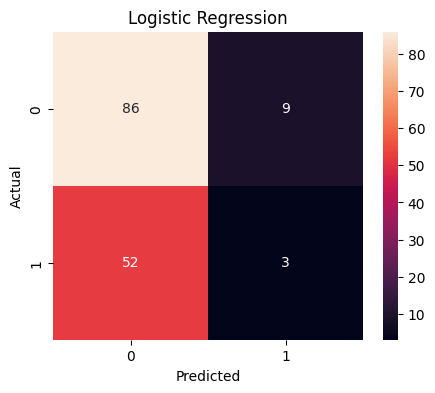

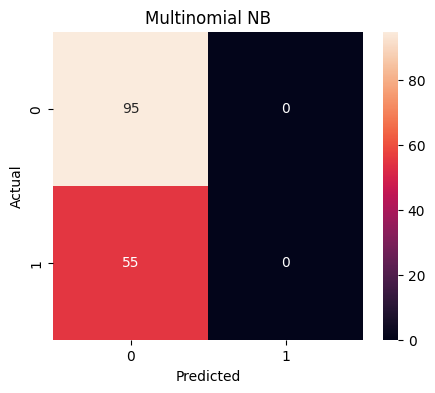

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test, y_pred_lr, "Logistic Regression")
plot_cm(y_test_mnb, y_pred_mnb, "Multinomial NB")